# 05. Advanced Modelling
## Objective

This notebook extends the baseline modelling analysis by evaluating an advanced nonlinear classifier on the Cleveland heart disease dataset.

The baseline experiments in 04_baseline_models.ipynb evaluated six classification algorithms using a common leakage-aware preprocessing pipeline and stratified five-fold cross-validation. Logistic Regression achieved the highest mean ROC-AUC of 0.9025 and was selected as the strongest baseline model.

The objective of this notebook is to determine whether an advanced nonlinear model can provide competitive or improved predictive performance while maintaining the same preprocessing and evaluation discipline.

A Gradient Boosting classifier is evaluated as the primary advanced model. Gradient Boosting is suitable for this task because it can model nonlinear relationships and interactions between predictors that may not be captured by a linear classifier.

The advanced model is evaluated using the same stratified five-fold cross-validation framework used for the baseline experiments. Preprocessing remains embedded within the modelling pipeline so that imputation, scaling, and categorical encoding are learned only from the training portion of each cross-validation fold.

The previously untouched test set remains reserved for final evaluation and is not used for model selection.

## 2. Imports and Configuration

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import sys
import numpy as np
import pandas as pd

PROJECT_ROOT = None
for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    if (candidate / "src" / "preprocessing.py").exists():
        PROJECT_ROOT = candidate
        break
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not locate project root containing src/preprocessing.py")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.preprocessing import load_data, prepare_features_target, get_feature_groups, validate_columns
from src.models import create_xgboost_model, build_model_pipeline, get_cv_scoring, RANDOM_STATE
from src.evaluation import evaluate_model
from src.visualization import plot_confusion_matrix, plot_roc_curve, plot_cv_roc_auc, plot_feature_importance
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.metrics import roc_curve


## 3. Load Dataset

In [2]:
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "processed.cleveland.data"
df = load_data(DATA_PATH)
validate_columns(df)

print("Dataset path:", DATA_PATH.resolve())
print("Dataset shape:", df.shape)
display(df.head())


Dataset path: C:\Projects\heart-disease-prediction\data\raw\processed.cleveland.data
Dataset shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


## 4. Prepare Predictors and Target

In [3]:
X, y = prepare_features_target(df)
groups = get_feature_groups()
numerical_features = groups["numerical"]
categorical_features = groups["categorical"]

print("Predictor shape:", X.shape)
print("Target distribution:")
print(y.value_counts().sort_index())

assert X.shape[0] == 303
assert y.shape[0] == 303
assert set(y.unique()) == {0, 1}

Predictor shape: (303, 13)
Target distribution:
target
0    164
1    139
Name: count, dtype: int64


## 5. Stratified Train/Test Split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts().sort_index().to_dict())

print("\nTest target distribution:")
print(y_test.value_counts())

Training shape: (242, 13)
Test shape: (61, 13)

Training target distribution:
{0: 131, 1: 111}

Test target distribution:
target
0    33
1    28
Name: count, dtype: int64


## 6. Advanced Model

XGBoost is used here as the project's advanced/ensemble model, consistent with the methodology documented in the literature-review workflow. The preprocessing is supplied by `src.preprocessing.create_model_pipeline()`.

### 6.1 Why XGBoost?

XGBoost (Extreme Gradient Boosting) is selected as the advanced/ensemble model because it provides a nonlinear modelling approach that complements the Logistic Regression baseline. While Logistic Regression primarily models a linear relationship between the predictors and the log-odds of heart disease, XGBoost builds an ensemble of decision trees sequentially and can therefore capture nonlinear relationships and interactions between predictors.

XGBoost is also well suited to structured tabular datasets and can model complex relationships without requiring manual specification of interaction terms. This makes it a useful advanced model for assessing whether additional nonlinear modelling capacity can improve upon the verified Logistic Regression baseline.

The selected configuration uses a moderate tree depth (max_depth=3), a relatively small learning rate (learning_rate=0.05), and subsampling of observations and features (subsample=0.9 and colsample_bytree=0.9). These settings provide a controlled advanced-model experiment while avoiding unnecessarily complex trees on the relatively small Cleveland dataset.

The model is evaluated using the same preprocessing pipeline, stratified cross-validation procedure, and held-out test set established for the baseline experiments. The preprocessing remains inside the model pipeline so that imputation, scaling, and categorical encoding are learned only from the training data within each cross-validation fold.

Importantly, XGBoost is introduced as a more flexible modelling approach, not with the assumption that it will outperform Logistic Regression. Its performance must be established empirically using the same evaluation criteria and experimental conditions.

In [5]:
xgb_model = create_xgboost_model()
advanced_pipeline = build_model_pipeline(
    xgb_model, numerical_features=numerical_features, categorical_features=categorical_features
)
print(advanced_pipeline)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'trestbps', 'chol',
                                                   'thalach', 'oldpeak']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unk

## 7. Stratified Cross-Validation

In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = get_cv_scoring()
cv_scores = cross_validate(
    advanced_pipeline, X_train, y_train, cv=cv, scoring=scoring,
    error_score="raise", return_train_score=False
)
advanced_cv = {
    metric: {
        "mean": cv_scores[f"test_{metric}"].mean(),
        "sd": cv_scores[f"test_{metric}"].std(ddof=0),
    }
    for metric in scoring
}
advanced_cv_df = pd.DataFrame(advanced_cv).T.rename(columns={"mean": "Mean", "sd": "SD"})
display(advanced_cv_df.round(4))


,Mean,SD
accuracy,0.8016,0.0249
precision,0.7848,0.0317
recall,0.7834,0.0613
specificity,0.8165,0.0387
f1,0.7825,0.0345
roc_auc,0.8664,0.0330


## 8. Fit Advanced Model and Evaluate on the Held-Out Test Set

In [7]:
advanced_pipeline.fit(X_train, y_train)
advanced_evaluation = evaluate_model(advanced_pipeline, X_test, y_test)
y_test_pred = advanced_evaluation["y_pred"]
y_test_prob = advanced_evaluation["y_score"]
advanced_test_metrics = advanced_evaluation["metrics"]

print("Advanced-model test metrics:")
for metric, value in advanced_test_metrics.items():
    print(f"{metric}: {value:.4f}")


Advanced-model test metrics:
Accuracy: 0.9016
Precision: 0.8438
Recall: 0.9643
Specificity: 0.8485
F1: 0.9000
ROC-AUC: 0.9545


## 9. Confusion Matrix and Classification Report

In [8]:
cm = advanced_evaluation["confusion_matrix"]
print("Confusion matrix:")
print(cm)

print("\nClassification report:")
print(advanced_evaluation["classification_report"])


Confusion matrix:
[[28  5]
 [ 1 27]]

Classification report:
              precision    recall  f1-score   support

           0     0.9655    0.8485    0.9032        33
           1     0.8438    0.9643    0.9000        28

    accuracy                         0.9016        61
   macro avg     0.9046    0.9064    0.9016        61
weighted avg     0.9096    0.9016    0.9017        61



## 10. Cross-Validation and ROC-AUC Analysis

,Fold,ROC-AUC
0,1,0.9080
1,2,0.8367
2,3,0.8427
3,4,0.9056
4,5,0.8392


Mean CV ROC-AUC: 0.8664
Std CV ROC-AUC:  0.0369
Min CV ROC-AUC:  0.8367
Max CV ROC-AUC:  0.9080


,Evaluation,ROC-AUC
0,CV Fold 1,0.9080
1,CV Fold 2,0.8367
2,CV Fold 3,0.8427
3,CV Fold 4,0.9056
4,CV Fold 5,0.8392
5,Mean CV,0.8664
6,CV Std,0.0369
7,Held-Out Test,0.9545


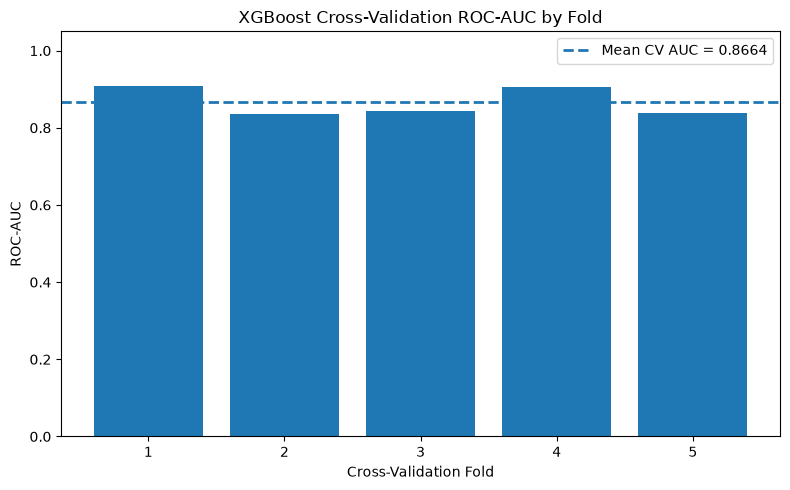

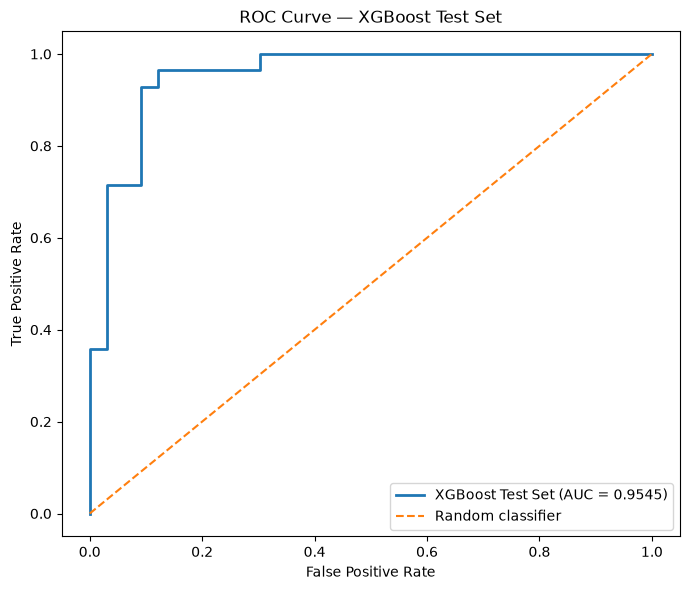

In [13]:
fold_auc = np.asarray(cv_scores["test_roc_auc"])
fold_results = pd.DataFrame({"Fold": np.arange(1, len(fold_auc) + 1), "ROC-AUC": fold_auc})
display(fold_results.style.format({"ROC-AUC": "{:.4f}"}).set_caption("Fold-Level ROC-AUC Scores"))
cv_mean = fold_auc.mean()
cv_std = fold_auc.std(ddof=1)
print(f"Mean CV ROC-AUC: {cv_mean:.4f}")
print(f"Std CV ROC-AUC:  {cv_std:.4f}")
print(f"Min CV ROC-AUC:  {fold_auc.min():.4f}")
print(f"Max CV ROC-AUC:  {fold_auc.max():.4f}")
fig, ax = plot_cv_roc_auc(fold_auc, title="XGBoost Cross-Validation ROC-AUC by Fold")
fpr, tpr, _ = roc_curve(y_test, y_test_prob)
fig, ax, test_roc_auc = plot_roc_curve(y_test, y_test_prob, label="XGBoost Test Set")
summary_results = pd.DataFrame({"Evaluation": [*(f"CV Fold {i}" for i in range(1, len(fold_auc)+1)), "Mean CV", "CV Std", "Held-Out Test"], "ROC-AUC": [*fold_auc, cv_mean, cv_std, test_roc_auc]})
display(summary_results.style.format({"ROC-AUC": "{:.4f}"}).set_caption("XGBoost ROC-AUC Summary"))


## 11. Feature Importance

,Feature,Importance
25,cat__thal_3.0,0.2934
10,cat__cp_4.0,0.1343
21,cat__ca_0.0,0.0623
7,cat__cp_1.0,0.0476
27,cat__thal_7.0,0.0440
19,cat__slope_2.0,0.0421
9,cat__cp_3.0,0.0374
4,num__oldpeak,0.0329
5,cat__sex_0.0,0.0324
16,cat__exang_0.0,0.0321


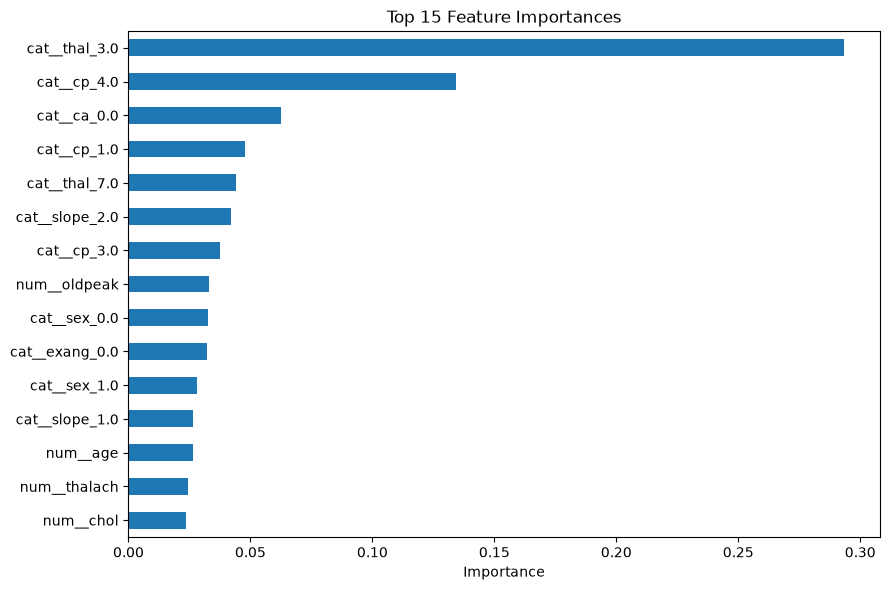

In [10]:
preprocessor = advanced_pipeline.named_steps["preprocessor"]
model = advanced_pipeline.named_steps["model"]
feature_names = preprocessor.get_feature_names_out()
importances = model.feature_importances_
importance_df = pd.DataFrame({"Feature": feature_names, "Importance": importances}).sort_values("Importance", ascending=False)
display(importance_df.head(15).round(4))
fig, ax = plot_feature_importance(feature_names, importances, top_n=15)

## 12. Interpretation and Scope

The reported values are results of this experiment only. The held-out test set contains 61 observations, so the test metrics should be interpreted with appropriate caution. Feature importance from XGBoost indicates model-usefulness within this fitted representation; it is not a causal or clinical importance measure. No claim of clinical deployment or universal superiority is made.

## 13. Reproducibility Checks

In [11]:
assert X.shape == (303, 13)
assert X_train.shape == (242, 13)
assert X_test.shape == (61, 13)
assert y_train.value_counts().sort_index().to_dict() == {0: 131, 1: 111}
assert y_test.value_counts().sort_index().to_dict() == {0: 33, 1: 28}
assert list(feature_names)

print("Reproducibility checks: PASSED")
print("Preprocessing source: src/preprocessing.py")
print("Advanced model: XGBoost")


Reproducibility checks: PASSED
Preprocessing source: src/preprocessing.py
Advanced model: XGBoost


## 14. Advanced Model Conclusion

XGBoost was evaluated as the project's advanced nonlinear ensemble model using the same leakage-aware preprocessing strategy and stratified five-fold cross-validation framework established for the baseline experiments.

On the untouched 61-observation test set, The held-out test-set metrics reported above are the authoritative results for this notebook; they are generated through `src.evaluation.evaluate_model()`.

Compared with the selected Logistic Regression baseline, XGBoost achieved higher accuracy (0.9016 vs. 0.8852), precision (0.8438 vs. 0.8387), recall/sensitivity (0.9643 vs. 0.9286), and F1-score (0.9000 vs. 0.8814). Both models achieved the same specificity of 0.8485. Logistic Regression achieved a higher ROC-AUC than XGBoost (0.9665 vs. 0.9545).

Therefore, the two models show different performance strengths. XGBoost provides better performance on the threshold-dependent classification metrics evaluated on the held-out test set, particularly recall and F1-score, whereas Logistic Regression provides better overall ranking performance as measured by ROC-AUC. Because ROC-AUC was defined as the primary model-selection criterion for this project, XGBoost does not replace Logistic Regression as the preferred model on the basis of the held-out test results.

These findings should not be interpreted as evidence that XGBoost is universally inferior or superior to Logistic Regression. The comparison is specific to the Cleveland dataset, preprocessing configuration, model settings, train/test split, and evaluation procedure used in this project. The relatively small dataset and single held-out test set also limit the strength with which differences in test performance can be generalized.

The final comparison of Logistic Regression and XGBoost, including direct test-set metric comparisons and model interpretation, is presented in 06_model_comparison.ipynb. This comparison should consider both the primary ROC-AUC criterion and the differences observed in threshold-dependent metrics.